In [1]:
!nvidia-smi

Wed Apr 29 21:09:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Dataset path resolution + unzip
# Veri kümesi yolu çözümü ve gerektiğinde zip aç.
import os, zipfile
from pathlib import Path

DRIVE_ZIP = "/content/drive/MyDrive/Sayzek/dataset_augmented_04_23_2026.zip"
DATA_ROOT = Path("/content/drive/MyDrive/Sayzek/dataset/dataset_augmented_04_23_2026/dataset_augmented")



In [4]:
!pip install pytorch-ignite openpyxl pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 12.0 MB/s eta 0:00:00


In [5]:
import random
import torch
import ignite

import random, numpy as np, torch

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [6]:
torch.__version__, ignite.__version__

('2.10.0+cu128', '0.5.4')

In [7]:
import torch
import torch.nn as nn


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class Flatten(nn.Module):
    def forward(self, x):
        return x.reshape(x.shape[0], -1)

Now let's define `SqueezeExcitation` module

In [8]:
class SqueezeExcitation(nn.Module):
    def __init__(self, inplanes, se_planes):
        super(SqueezeExcitation, self).__init__()
        self.reduce_expand = nn.Sequential(
            nn.Conv2d(inplanes, se_planes, kernel_size=1, stride=1, padding=0, bias=True),
            Swish(),
            nn.Conv2d(se_planes, inplanes, kernel_size=1, stride=1, padding=0, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x_se = torch.mean(x, dim=(-2, -1), keepdim=True)
        x_se = self.reduce_expand(x_se)
        return x_se * x

In [9]:
from torch.nn import functional as F


class MBConv(nn.Module):
    def __init__(self, inplanes, planes, kernel_size, stride, expand_rate=1.0, se_rate=0.25, drop_connect_rate=0.2):
        super(MBConv, self).__init__()

        expand_planes = int(inplanes * expand_rate)
        se_planes = max(1, int(inplanes * se_rate))

        self.expansion_conv = None
        if expand_rate > 1.0:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(inplanes, expand_planes, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
                Swish(),
            )
            inplanes = expand_planes

        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(
                inplanes,
                expand_planes,
                kernel_size=kernel_size,
                stride=stride,
                padding=kernel_size // 2,
                groups=expand_planes,
                bias=False,
            ),
            nn.BatchNorm2d(expand_planes, momentum=0.01, eps=1e-3),
            Swish(),
        )

        self.squeeze_excitation = SqueezeExcitation(expand_planes, se_planes)

        self.project_conv = nn.Sequential(
            nn.Conv2d(expand_planes, planes, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(planes, momentum=0.01, eps=1e-3),
        )

        self.with_skip = stride == 1
        self.drop_connect_rate = drop_connect_rate

    def _drop_connect(self, x):
        keep_prob = 1.0 - self.drop_connect_rate
        drop_mask = torch.rand(x.shape[0], 1, 1, 1) + keep_prob
        drop_mask = drop_mask.type_as(x)
        drop_mask.floor_()
        return drop_mask * x / keep_prob

    def forward(self, x):
        z = x
        if self.expansion_conv is not None:
            x = self.expansion_conv(x)

        x = self.depthwise_conv(x)
        x = self.squeeze_excitation(x)
        x = self.project_conv(x)

        # Add identity skip
        if x.shape == z.shape and self.with_skip:
            if self.training and self.drop_connect_rate is not None:
                x = self._drop_connect(x)
            x += z
        return x

And finally, we can implement generic `EfficientNet`:

In [10]:
from collections import OrderedDict
import math


def init_weights(module):
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, a=0, mode="fan_out")
    elif isinstance(module, nn.Linear):
        init_range = 1.0 / math.sqrt(module.weight.shape[1])
        nn.init.uniform_(module.weight, a=-init_range, b=init_range)


class EfficientNet(nn.Module):
    def _setup_repeats(self, num_repeats):
        return int(math.ceil(self.depth_coefficient * num_repeats))

    def _setup_channels(self, num_channels):
        num_channels *= self.width_coefficient
        new_num_channels = math.floor(num_channels / self.divisor + 0.5) * self.divisor
        new_num_channels = max(self.divisor, new_num_channels)
        if new_num_channels < 0.9 * num_channels:
            new_num_channels += self.divisor
        return new_num_channels

    def __init__(
        self,
        num_classes=100,
        width_coefficient=1.0,
        depth_coefficient=1.0,
        se_rate=0.25,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
    ):
        super(EfficientNet, self).__init__()

        self.width_coefficient = width_coefficient
        self.depth_coefficient = depth_coefficient
        self.divisor = 8

        list_channels = [32, 16, 24, 40, 80, 112, 192, 320, 1280]
        list_channels = [self._setup_channels(c) for c in list_channels]

        list_num_repeats = [1, 2, 2, 3, 3, 4, 1]
        list_num_repeats = [self._setup_repeats(r) for r in list_num_repeats]

        expand_rates = [1, 6, 6, 6, 6, 6, 6]
        strides = [1, 2, 2, 2, 1, 2, 1]
        kernel_sizes = [3, 3, 5, 3, 5, 5, 3]

        # Define stem:
        self.stem = nn.Sequential(
            nn.Conv2d(3, list_channels[0], kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(list_channels[0], momentum=0.01, eps=1e-3),
            Swish(),
        )

        # Define MBConv blocks
        blocks = []
        counter = 0
        num_blocks = sum(list_num_repeats)
        for idx in range(7):
            num_channels = list_channels[idx]
            next_num_channels = list_channels[idx + 1]
            num_repeats = list_num_repeats[idx]
            expand_rate = expand_rates[idx]
            kernel_size = kernel_sizes[idx]
            stride = strides[idx]
            drop_rate = drop_connect_rate * counter / num_blocks

            name = "MBConv{}_{}".format(expand_rate, counter)
            blocks.append(
                (
                    name,
                    MBConv(
                        num_channels,
                        next_num_channels,
                        kernel_size=kernel_size,
                        stride=stride,
                        expand_rate=expand_rate,
                        se_rate=se_rate,
                        drop_connect_rate=drop_rate,
                    ),
                )
            )
            counter += 1
            for i in range(1, num_repeats):
                name = "MBConv{}_{}".format(expand_rate, counter)
                drop_rate = drop_connect_rate * counter / num_blocks
                blocks.append(
                    (
                        name,
                        MBConv(
                            next_num_channels,
                            next_num_channels,
                            kernel_size=kernel_size,
                            stride=1,
                            expand_rate=expand_rate,
                            se_rate=se_rate,
                            drop_connect_rate=drop_rate,
                        ),
                    )
                )
                counter += 1

        self.blocks = nn.Sequential(OrderedDict(blocks))

        # Define head
        self.head = nn.Sequential(
            nn.Conv2d(list_channels[-2], list_channels[-1], kernel_size=1, bias=False),
            nn.BatchNorm2d(list_channels[-1], momentum=0.01, eps=1e-3),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(list_channels[-1], num_classes),
        )

        self.apply(init_weights)

    def forward(self, x):
        f = self.stem(x)
        f = self.blocks(f)
        y = self.head(f)
        return y

All EfficientNet models can be defined using the following parametrization:
```
# (width_coefficient, depth_coefficient, resolution, dropout_rate)
'efficientnet-b0': (1.0, 1.0, 224, 0.2),
'efficientnet-b1': (1.0, 1.1, 240, 0.2),
'efficientnet-b2': (1.1, 1.2, 260, 0.3),
'efficientnet-b3': (1.2, 1.4, 300, 0.3),
'efficientnet-b4': (1.4, 1.8, 380, 0.4),
'efficientnet-b5': (1.6, 2.2, 456, 0.4),
'efficientnet-b6': (1.8, 2.6, 528, 0.5),
'efficientnet-b7': (2.0, 3.1, 600, 0.5),
```    
Let's define and train the third one: `EfficientNet-B0`

In [11]:
model = EfficientNet(num_classes=1000, width_coefficient=1.0, depth_coefficient=1.0, dropout_rate=0.2)

Number of parameters:

In [12]:
def print_num_params(model, display_all_modules=False):
    total_num_params = 0
    for n, p in model.named_parameters():
        num_params = 1
        for s in p.shape:
            num_params *= s
        if display_all_modules:
            print("{}: {}".format(n, num_params))
        total_num_params += num_params
    print("-" * 50)
    print("Total number of parameters: {:.2e}".format(total_num_params))


print_num_params(model)

--------------------------------------------------
Total number of parameters: 5.29e+06


### Load pretrained weights

Let's load pretrained weights and check the model on a single image.

In [13]:
!mkdir /tmp/efficientnet_weights
!wget http://storage.googleapis.com/public-models/efficientnet-b0-08094119.pth -O/tmp/efficientnet_weights/efficientnet-b0-08094119.pth

--2026-04-29 21:09:47--  http://storage.googleapis.com/public-models/efficientnet-b0-08094119.pth
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.142.207, 74.125.195.207, 172.253.117.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.142.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21383481 (20M) [application/octet-stream]
Saving to: ‘/tmp/efficientnet_weights/efficientnet-b0-08094119.pth’

/tmp/efficientnet_w 100%[===================>]  20.39M  --.-KB/s    in 0.1s    

2026-04-29 21:09:47 (179 MB/s) - ‘/tmp/efficientnet_weights/efficientnet-b0-08094119.pth’ saved [21383481/21383481]



In [14]:
from collections import OrderedDict

model_state = torch.load("/tmp/efficientnet_weights/efficientnet-b0-08094119.pth")

# A basic remapping is required
mapping = {k: v for k, v in zip(model_state.keys(), model.state_dict().keys())}
mapped_model_state = OrderedDict([(mapping[k], v) for k, v in model_state.items()])

model.load_state_dict(mapped_model_state, strict=False)

<All keys matched successfully>

In [17]:
# === PATH SETUP (unconditional) ===
# Bu hucre hangi siradan calistirilirsa calistirilsin path'leri kurar.
from pathlib import Path
import os, zipfile

DRIVE_ZIP = "/content/drive/MyDrive/Sayzek/dataset_augmented_04_23_2026.zip"
DATA_ROOT = Path("/content/dataset/dataset_augmented")

if not DATA_ROOT.exists():
    if not Path("/content/drive/MyDrive").exists():
        from google.colab import drive
        drive.mount("/content/drive")
    os.makedirs("/content/dataset", exist_ok=True)
    print(f"Unzipping {DRIVE_ZIP} -> /content/dataset/")
    with zipfile.ZipFile(DRIVE_ZIP) as z:
        z.extractall("/content/dataset")

assert DATA_ROOT.exists(), f"DATA_ROOT missing: {DATA_ROOT}"

TRAIN_ANN = DATA_ROOT / "train" / "_annotations.coco.json"
VAL_ANN   = DATA_ROOT / "val"   / "_annotations.coco.json"
TEST_ANN  = DATA_ROOT / "test"  / "_annotations.coco.json"
TRAIN_IMG = DATA_ROOT / "train" / "images"
VAL_IMG   = DATA_ROOT / "val"   / "images"
TEST_IMG  = DATA_ROOT / "test"  / "images"

for p in [TRAIN_ANN, VAL_ANN, TEST_ANN, TRAIN_IMG, VAL_IMG, TEST_IMG]:
    assert p.exists(), f"missing: {p}"
print(f"PATHS OK -> {DATA_ROOT}")

# COCO bbox classifier dataset (thermal: Person / Car / OtherVehicle)
# Her annotation bir bbox kirpima donusur, EfficientNet siniflandirici girisi olur.
import json as _json
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import Compose, Resize, RandomCrop, RandomHorizontalFlip, ToTensor, Normalize
from PIL.Image import BICUBIC


class CocoBBoxClassifier(Dataset):
    # ann_path: COCO JSON. images_dir: image klasoru. transform: torchvision transforms.
    def __init__(self, ann_path, images_dir, transform=None, min_side=4):
        with open(ann_path, "r") as f:
            data = _json.load(f)
        self.images_dir = Path(images_dir)
        self.transform  = transform

        cats = sorted(data["categories"], key=lambda c: c["id"])
        self.cat_id_to_idx = {c["id"]: i for i, c in enumerate(cats)}
        self.class_names   = [c["name"] for c in cats]

        id_to_file = {im["id"]: im["file_name"] for im in data["images"]}

        self.samples = []
        for ann in data["annotations"]:
            x, y, w, h = ann["bbox"]
            if w < min_side or h < min_side:
                continue
            self.samples.append((id_to_file[ann["image_id"]],
                                 (float(x), float(y), float(w), float(h)),
                                 self.cat_id_to_idx[ann["category_id"]]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, (x, y, w, h), cls = self.samples[idx]
        img  = Image.open(self.images_dir / fname).convert("RGB")
        crop = img.crop((x, y, x + w, y + h))
        if self.transform is not None:
            crop = self.transform(crop)
        return crop, cls


train_transform = Compose([
    Resize((256, 256), BICUBIC),
    RandomCrop(224),
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = Compose([
    Resize((224, 224), BICUBIC),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = CocoBBoxClassifier(TRAIN_ANN, TRAIN_IMG, transform=train_transform)
val_dataset   = CocoBBoxClassifier(VAL_ANN,   VAL_IMG,   transform=test_transform)
test_dataset  = CocoBBoxClassifier(TEST_ANN,  TEST_IMG,  transform=test_transform)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

train_eval_indices = [random.randint(0, len(train_dataset) - 1)
                      for _ in range(min(len(val_dataset), len(train_dataset)))]
train_eval_dataset = Subset(train_dataset, train_eval_indices)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}  TrainEval: {len(train_eval_dataset)}")


PATHS OK -> /content/dataset/dataset_augmented
Classes (3): ['Person', 'Car', 'OtherVehicle']
Train: 570171  Val: 8269  Test: 138247  TrainEval: 8269


In [18]:
# GPU'ya gore batch + workers (T4 = 16GB, A100 = 40GB+).
import torch as _torch

_gpu_name = _torch.cuda.get_device_name(0) if _torch.cuda.is_available() else ""
print(f"GPU: {_gpu_name}")

if "A100" in _gpu_name:
    batch_size  = 256
    num_workers = 8
elif "T4" in _gpu_name:
    batch_size  = 64
    num_workers = 2
else:
    batch_size  = 32
    num_workers = 2

print(f"batch_size={batch_size}  num_workers={num_workers}")

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=True, drop_last=True, pin_memory=True, persistent_workers=(num_workers > 0),
)

# Val seti birincil degerlendirme seti.
test_loader = DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=False, drop_last=False, pin_memory=True, persistent_workers=(num_workers > 0),
)

eval_train_loader = DataLoader(
    train_eval_dataset, batch_size=batch_size, num_workers=num_workers,
    shuffle=False, drop_last=False, pin_memory=True, persistent_workers=(num_workers > 0),
)


GPU: Tesla T4
batch_size=64  num_workers=2


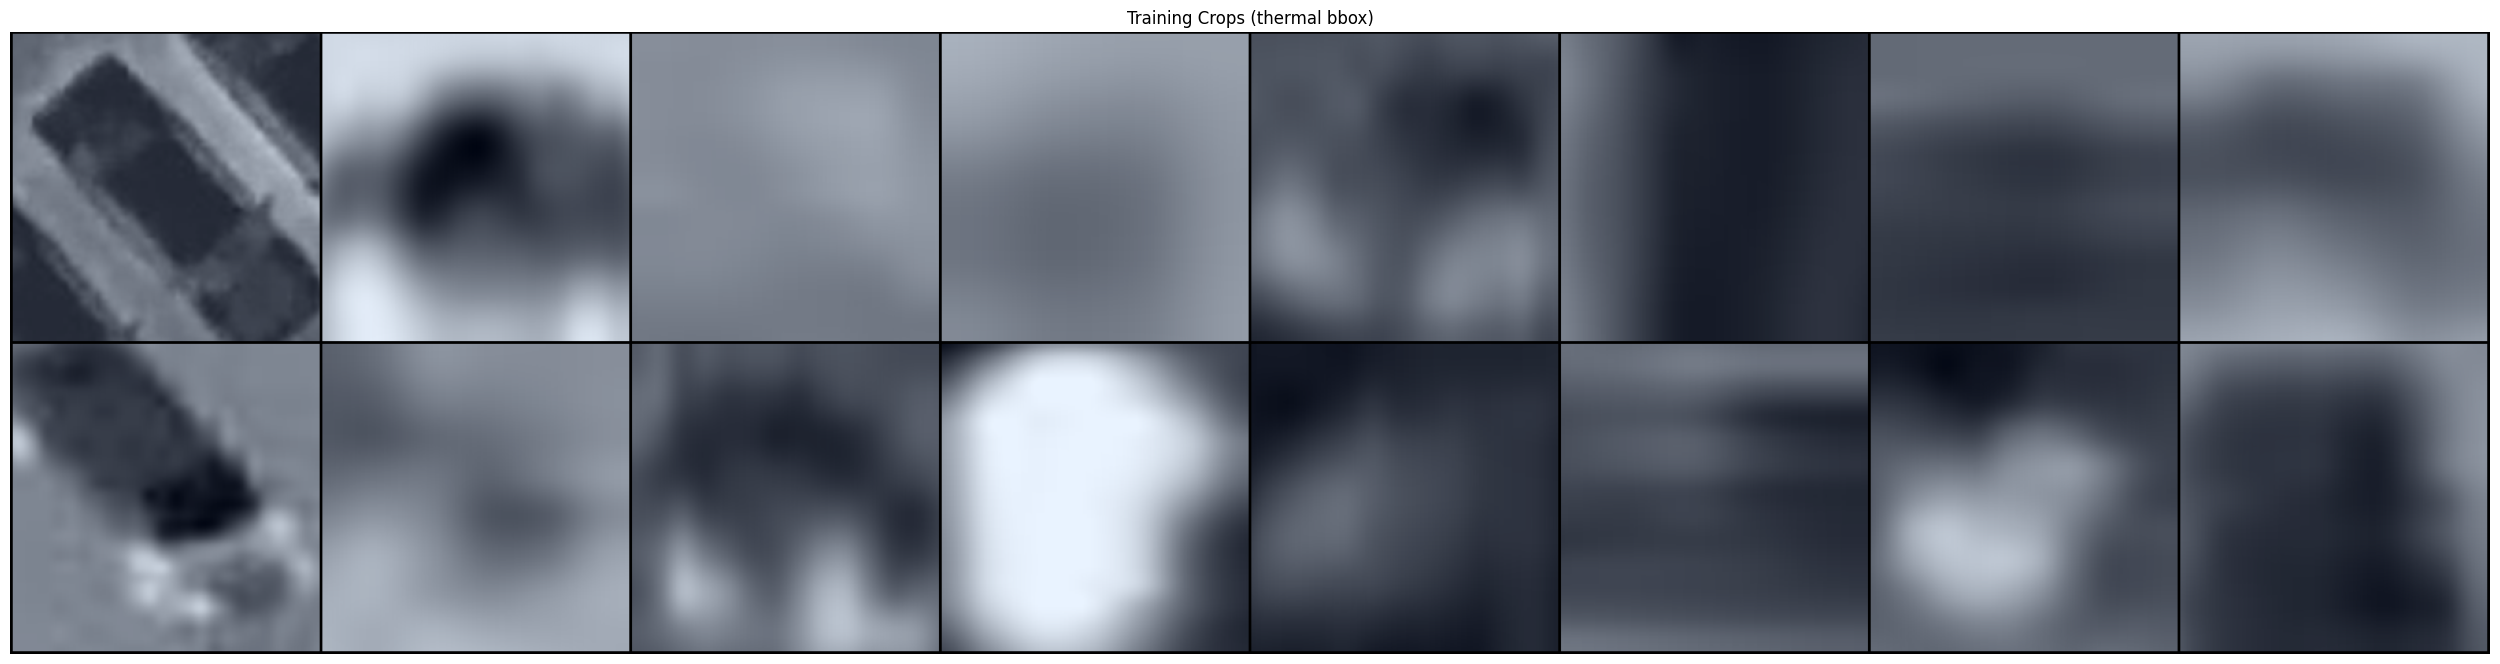

In [22]:
import matplotlib.pyplot as plt
# Preview: birkac batch goruntu
import torchvision.utils as vutils

batch = next(iter(train_loader))
plt.figure(figsize=(32, 32))
plt.axis("off")
plt.title("Training Crops (thermal bbox)")
plt.imshow(vutils.make_grid(batch[0][:16], padding=2, normalize=True).cpu().numpy().transpose((1, 2, 0)))

batch = None
torch.cuda.empty_cache()


## Finetunning model

As we are interested to finetune the model to CIFAR-100, we will replace the classification fully-connected layer (ImageNet-1000 vs CIFAR-100).

In [23]:
model.head[6].in_features, model.head[6].out_features

(1280, 1000)

In [24]:
model.head[6] = nn.Linear(1280, NUM_CLASSES)

In [25]:
model.head[6].in_features, model.head[6].out_features

(1280, 3)

Karma hassasiyet (mixed precision): `torch.cuda.amp` (native AMP). Hem T4 hem A100 destekler.

In [26]:
assert torch.cuda.is_available()
assert torch.backends.cudnn.enabled, "torch.cuda.amp requires cudnn backend."
torch.backends.cudnn.benchmark = True

device = "cuda"


In [27]:
model = model.to(device)

In [28]:
from itertools import chain

import torch.optim as optim
import torch.nn.functional as F


criterion = nn.CrossEntropyLoss()

lr = 0.01

optimizer = optim.SGD(
    [
        {
            "params": chain(model.stem.parameters(), model.blocks.parameters()),
            "lr": lr * 0.1,
        },
        {
            "params": model.head[:6].parameters(),
            "lr": lr * 0.2,
        },
        {"params": model.head[6].parameters(), "lr": lr},
    ],
    momentum=0.9,
    weight_decay=0.001,
    nesterov=True,
)

In [29]:
from torch.optim.lr_scheduler import ExponentialLR

lr_scheduler = ExponentialLR(optimizer, gamma=0.975)

In [30]:
# torch.cuda.amp ile karma hassasiyet (T4 + A100 destekler).
from torch.amp import GradScaler

scaler = GradScaler("cuda")


/tmp/ipykernel_4644/911013505.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Next, let's define a single iteration function `update_fn`. This function is then used by `ignite.engine.Engine` to update model while running over the input data.

In [31]:
from ignite.utils import convert_tensor
from torch.amp import autocast


def update_fn(engine, batch):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    x = convert_tensor(batch[0], device=device, non_blocking=True)
    y = convert_tensor(batch[1], device=device, non_blocking=True)

    with autocast("cuda"):
        y_pred = model(x)
        loss   = criterion(y_pred, y)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    return {"batchloss": loss.item()}


Let's check `update_fn`

In [32]:
batch = next(iter(train_loader))

res = update_fn(engine=None, batch=batch)

batch = None
torch.cuda.empty_cache()

res

/tmp/ipykernel_4644/1054453079.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


{'batchloss': 1.1155014038085938}

Now let's define a trainer and add some practical handlers:
- log to tensorboard: losses, metrics, lr
- progress bar
- models/optimizers checkpointing

In [33]:
from ignite.engine import Engine, Events, create_supervised_evaluator
from ignite.metrics import RunningAverage, Accuracy, Precision, Recall, Loss


In [34]:
trainer = Engine(update_fn)


def output_transform(out):
    return out["batchloss"]


RunningAverage(output_transform=output_transform).attach(trainer, "batchloss")

In [35]:
from datetime import datetime

exp_name = datetime.now().strftime("%Y%m%d-%H%M%S")
log_path = "/content/drive/MyDrive/sayzek_runs_efficientnet_b0_thermal/{}".format(exp_name)
import os
os.makedirs(log_path, exist_ok=True)
print("Experiment name:", exp_name)
print("Log path:", log_path)


Experiment name: 20260429-211328
Log path: /content/drive/MyDrive/sayzek_runs_efficientnet_b0_thermal/20260429-211328


Let's setup learning rate scheduling:

In [36]:
trainer.add_event_handler(Events.EPOCH_COMPLETED, lambda engine: lr_scheduler.step())


In [37]:
from ignite.handlers import ProgressBar

# Iteration-wise progress bar (batch ilerleme).
ProgressBar(persist=False, desc="Iter").attach(trainer, metric_names=["batchloss"])

# Epoch-wise progress bar (epoch sayaci).
ProgressBar(persist=True, desc="Epoch", bar_format="").attach(
    trainer, event_name=Events.EPOCH_STARTED, closing_event_name=Events.COMPLETED
)


/usr/local/lib/python3.12/dist-packages/ignite/handlers/tqdm_logger.py:129: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Let's create two evaluators to compute metrics on train/test images and log them to Tensorboard:

In [38]:
metrics = {
    "Loss": Loss(criterion),
    "Accuracy": Accuracy(),
    "Precision": Precision(average=True),
    "Recall": Recall(average=True)
}


evaluator = create_supervised_evaluator(model, metrics=metrics, device=device, non_blocking=True)

train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device, non_blocking=True)

In [39]:
def run_evaluation(engine):
    train_evaluator.run(eval_train_loader)
    evaluator.run(test_loader)


trainer.add_event_handler(Events.EPOCH_STARTED(every=3), run_evaluation)
trainer.add_event_handler(Events.COMPLETED, run_evaluation)


Now let's setup the best model checkpointing, early stopping:

In [40]:
import logging


# Setup engine &  logger
def setup_logger(logger):
    handler = logging.StreamHandler()
    formatter = logging.Formatter("%(asctime)s %(name)-12s %(levelname)-8s %(message)s")
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)

In [41]:
from ignite.handlers import Checkpoint, DiskSaver, EarlyStopping, TerminateOnNan

# Egitim kontrolu: NaN saptarsa durdurur.
trainer.add_event_handler(Events.ITERATION_COMPLETED, TerminateOnNan())


# Best model: val Accuracy en yuksek olan kaydedilir.
def score_fn(engine):
    return engine.state.metrics["Accuracy"]


disk_saver = DiskSaver(dirname=log_path, require_empty=False)
best_model_handler = Checkpoint(
    to_save={"model": model},
    save_handler=disk_saver,
    filename_pattern="{name}.{ext}",
    score_function=score_fn,
    score_name="val_acc",
    n_saved=1,
)
evaluator.add_event_handler(Events.COMPLETED, best_model_handler)

# Early stopping: val Accuracy `ES_PATIENCE` degerlendirme adimi boyunca artmazsa durur.
# Eval `Events.EPOCH_STARTED(every=3)` => her 3 epoch'ta bir => gercek bekleme = 3 * ES_PATIENCE epoch.
ES_PATIENCE = 8
es_handler = EarlyStopping(
    patience=ES_PATIENCE,
    score_function=score_fn,
    trainer=trainer,
    min_delta=1e-4,
)
evaluator.add_event_handler(Events.COMPLETED, es_handler)
setup_logger(es_handler.logger)


# CUDA cache temizle.
def empty_cuda_cache(engine):
    torch.cuda.empty_cache()
    import gc
    gc.collect()


trainer.add_event_handler(Events.EPOCH_COMPLETED, empty_cuda_cache)
evaluator.add_event_handler(Events.COMPLETED, empty_cuda_cache)
train_evaluator.add_event_handler(Events.COMPLETED, empty_cuda_cache)

print(f"EarlyStopping ready: patience={ES_PATIENCE} (eval interval 3 epoch -> ~{3*ES_PATIENCE} epoch)")


EarlyStopping ready: patience=8 (eval interval 3 epoch -> ~24 epoch)


### Excel epoch logger (per-epoch metrics → xlsx)

Her epoch sonunda train/val metriklerini Excel'e yazar. Ignite EPOCH_COMPLETED hook'una baglanir.

In [42]:
# Excel epoch logger
# Her epoch sonunda train/val metrikleri xlsx'e yazilir.
from pathlib import Path
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

EXCEL_PATH = Path(log_path) / "training_metrics.xlsx"
EXCEL_PATH.parent.mkdir(parents=True, exist_ok=True)

HEADERS = [
    "Epoch", "Learning Rate",
    "Train Loss", "Train Accuracy", "Train Precision", "Train Recall",
    "Val Loss",   "Val Accuracy",   "Val Precision",   "Val Recall",
]

_THIN       = Side(border_style="thin", color="BBBBBB")
BORDER      = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)
HEADER_FILL = PatternFill("solid", start_color="1F3864")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
DATA_FONT   = Font(name="Arial", size=10)


def _build_workbook(path: Path) -> None:
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Training Metrics"
    for ci, val in enumerate(HEADERS, 1):
        c = ws.cell(row=1, column=ci, value=val)
        c.fill = HEADER_FILL
        c.font = HEADER_FONT
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        c.border = BORDER
        ws.column_dimensions[get_column_letter(ci)].width = 16
    ws.row_dimensions[1].height = 38
    ws.freeze_panes = "A2"
    wb.save(path)


def _append_row(path: Path, values: list) -> None:
    wb = openpyxl.load_workbook(path)
    ws = wb["Training Metrics"]
    r = ws.max_row + 1
    alt = PatternFill("solid", start_color="EBF3FB") if r % 2 == 0 else None
    for ci, val in enumerate(values, 1):
        c = ws.cell(row=r, column=ci, value=val)
        c.font = DATA_FONT
        c.alignment = Alignment(horizontal="center")
        c.border = BORDER
        if alt:
            c.fill = alt
    wb.save(path)


def _fmt(v):
    return None if v is None else round(float(v), 4)


if not EXCEL_PATH.exists():
    _build_workbook(EXCEL_PATH)


_last_train_metrics = {}


@train_evaluator.on(Events.COMPLETED)
def _cache_train_metrics(engine):
    _last_train_metrics.clear()
    _last_train_metrics.update(engine.state.metrics)


@evaluator.on(Events.COMPLETED)
def _write_epoch_row(engine):
    epoch  = trainer.state.epoch
    lr_val = optimizer.param_groups[-1]["lr"]
    val_m  = engine.state.metrics
    tr_m   = _last_train_metrics

    row = [
        epoch, round(lr_val, 8),
        _fmt(tr_m.get("Loss")),
        _fmt(tr_m.get("Accuracy")),
        _fmt(tr_m.get("Precision")),
        _fmt(tr_m.get("Recall")),
        _fmt(val_m.get("Loss")),
        _fmt(val_m.get("Accuracy")),
        _fmt(val_m.get("Precision")),
        _fmt(val_m.get("Recall")),
    ]
    _append_row(EXCEL_PATH, row)


print(f"Excel logger ready: {EXCEL_PATH}")


Excel logger ready: /content/drive/MyDrive/sayzek_runs_efficientnet_b0_thermal/20260429-211328/training_metrics.xlsx


In [ ]:
import time
_epoch_t = {"t": 0.0}

@trainer.on(Events.EPOCH_STARTED)
def _t0(engine):
    _epoch_t["t"] = time.time()

@trainer.on(Events.EPOCH_COMPLETED)
def _t1(engine):
    dt = time.time() - _epoch_t["t"]
    print(f"[Epoch {engine.state.epoch}] sure: {dt:.1f} s")


In [ ]:
num_epochs = 1


trainer.run(train_loader, max_epochs=num_epochs)

100%|##########| 1/1 [00:00<?, ?it/s]

/tmp/ipykernel_4644/1054453079.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


### Post-training plots (xlsx → matplotlib)

Yazilan `training_metrics.xlsx`'i okur, train/val grafiklerini cizer ve PNG'leri `log_path/plots/`'a kaydeder.

In [ ]:
# Post-training: xlsx -> matplotlib plots
# Egitim sonrasi: xlsx -> grafikler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PLOTS_DIR = Path(log_path) / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

LW   = 2.0
DPI  = 150
SKIP = 0
FMT  = "png"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#cccccc",
})

df = pd.read_excel(EXCEL_PATH, sheet_name="Training Metrics", engine="openpyxl")
df = df.sort_values("Epoch").reset_index(drop=True)
df = df[df["Epoch"] > SKIP].reset_index(drop=True)

epoch = df["Epoch"].to_numpy()


def _arr(col):
    return df[col].to_numpy(dtype=np.float64) if col in df.columns else np.full_like(epoch, np.nan, dtype=np.float64)


t_loss = _arr("Train Loss")
v_loss = _arr("Val Loss")
t_acc  = _arr("Train Accuracy")
v_acc  = _arr("Val Accuracy")
t_p    = _arr("Train Precision")
v_p    = _arr("Val Precision")
t_r    = _arr("Train Recall")
v_r    = _arr("Val Recall")
lr_arr = _arr("Learning Rate")


def _style(ax, ep, title, ylabel):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if len(ep) > 0:
        ax.set_xlim(ep[0], ep[-1])
    ax.legend()


# Loss
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_loss, color="#2166AC", linewidth=LW, label="Train Loss")
ax.plot(epoch, v_loss, color="#D73027", linewidth=LW, linestyle="--", label="Validation Loss")
_style(ax, epoch, "Loss", "Loss")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"loss.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Accuracy
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_acc, color="#1A9850", linewidth=LW, label="Train Accuracy")
ax.plot(epoch, v_acc, color="#74C476", linewidth=LW, linestyle="--", label="Validation Accuracy")
_style(ax, epoch, "Accuracy", "Accuracy")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"accuracy.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Precision / Recall
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_p, color="#2166AC", linewidth=LW, label="Train Precision")
ax.plot(epoch, v_p, color="#2166AC", linewidth=LW, linestyle="--", label="Val Precision")
ax.plot(epoch, t_r, color="#D73027", linewidth=LW, label="Train Recall")
ax.plot(epoch, v_r, color="#D73027", linewidth=LW, linestyle="--", label="Val Recall")
_style(ax, epoch, "Precision & Recall", "Score")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"precision_recall.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# LR
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, lr_arr, color="#6A3D9A", linewidth=LW, label="Learning Rate")
_style(ax, epoch, "Learning Rate", "LR")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"lr.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Dashboard
fig = plt.figure(figsize=(15, 9))
fig.suptitle("EfficientNet — Egitim Metrikleri (Thermal)", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epoch, t_loss, color="#2166AC", linewidth=LW, label="Train")
ax1.plot(epoch, v_loss, color="#D73027", linewidth=LW, linestyle="--", label="Val")
_style(ax1, epoch, "Loss", "Loss")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epoch, t_acc, color="#1A9850", linewidth=LW, label="Train")
ax2.plot(epoch, v_acc, color="#74C476", linewidth=LW, linestyle="--", label="Val")
_style(ax2, epoch, "Accuracy", "Accuracy")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epoch, lr_arr, color="#6A3D9A", linewidth=LW, label="LR")
_style(ax3, epoch, "Learning Rate", "LR")

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epoch, t_p, color="#2166AC", linewidth=LW, label="Train")
ax4.plot(epoch, v_p, color="#D73027", linewidth=LW, linestyle="--", label="Val")
_style(ax4, epoch, "Precision", "Precision")

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epoch, t_r, color="#2166AC", linewidth=LW, label="Train")
ax5.plot(epoch, v_r, color="#D73027", linewidth=LW, linestyle="--", label="Val")
_style(ax5, epoch, "Recall", "Recall")

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")

fig.savefig(PLOTS_DIR / f"dashboard.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

print(f"Plots saved to: {PLOTS_DIR}")
for f in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  {f.name}")


Finetunning results:

- Test dataset:

In [ ]:
evaluator.state.metrics

- Training subset:

In [ ]:
train_evaluator.state.metrics

Obviously, our training settings is not the optimal one and the delta between our result and the paper's one is about 5%.

## Inference

Let's load the best model and recompute evaluation metrics on test dataset with a very basic Test-Time-Augmentation to boost the performances.


In [ ]:
best_model = EfficientNet(num_classes=1000, width_coefficient=1.0, depth_coefficient=1.0, dropout_rate=0.2)
best_model.head[6] = nn.Linear(1280, NUM_CLASSES)
best_model.load_state_dict(torch.load(log_path + "/model.pt"))


In [ ]:
metrics = {
    "Accuracy": Accuracy(),
    "Precision": Precision(average=True),
    "Recall": Recall(average=True),
}


def inference_update_with_tta(engine, batch):
    best_model.eval()
    with torch.no_grad():
        x, y = batch
        # Let's compute final prediction as a mean of predictions on x and flipped x
        y_pred1 = best_model(x)
        y_pred2 = best_model(x.flip(dims=(-1,)))
        y_pred = 0.5 * (y_pred1 + y_pred2)

        return y_pred, y


inferencer = Engine(inference_update_with_tta)

In [ ]:
for name, metric in metrics.items():
    metric.attach(inferencer, name)

In [ ]:
ProgressBar(desc="Inference").attach(inferencer)

In [ ]:
result_state = inferencer.run(test_loader, max_epochs=1)

Finally, we obtain similar scores:

In [ ]:
result_state.metrics